#SETUP & LOAD DATA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

# Load data
PATH = "/content/final_dataset_clean.csv"
df = pd.read_csv(PATH, sep=';')

print("Data Loaded. Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())
print("\nData Info:")
print(df.info())

Data Loaded. Shape: (10000, 23)

Column Names:
['customer_id', 'plan_type', 'device_brand', 'avg_data_usage_gb', 'pct_video_usage', 'avg_call_duration', 'sms_freq', 'monthly_spend', 'topup_freq', 'travel_score', 'complain_count', 'product_id', 'product_name', 'price', 'duration_days', 'data_gb', 'streaming_gb_bonus', 'gaming_gb_bonus', 'social_gb_bonus', 'call_minutes_bonus', 'sms_bonus', 'roaming_days_bonus', 'target_offer']

First few rows:
  customer_id plan_type device_brand  avg_data_usage_gb  pct_video_usage  \
0      C00001   Prepaid         Vivo              17.17            0.767   
1      C00002  Postpaid         Vivo              23.19            0.356   
2      C00003   Prepaid       Realme              27.85            0.441   
3      C00004   Prepaid       Xiaomi               7.91            0.279   
4      C00005   Prepaid         Vivo              10.11            0.974   

   avg_call_duration  sms_freq  monthly_spend  topup_freq  travel_score  ...  \
0             19

#DATA CLEANING & VALIDATION

In [2]:
required_cols = ['customer_id', 'product_id', 'avg_data_usage_gb', 'monthly_spend', 'pct_video_usage']
missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    print(f"\n⚠️ WARNING: Kolom berikut tidak ditemukan: {missing_cols}")
    print("Silakan cek nama kolom di dataset Anda!")
    # Uncomment baris di bawah jika ingin stop eksekusi
    # raise ValueError(f"Missing columns: {missing_cols}")

# Handle missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Fill missing values with appropriate defaults
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(0)


Missing values per column:
customer_id           0
plan_type             0
device_brand          0
avg_data_usage_gb     0
pct_video_usage       0
avg_call_duration     0
sms_freq              0
monthly_spend         0
topup_freq            0
travel_score          0
complain_count        0
product_id            0
product_name          0
price                 0
duration_days         0
data_gb               0
streaming_gb_bonus    0
gaming_gb_bonus       0
social_gb_bonus       0
call_minutes_bonus    0
sms_bonus             0
roaming_days_bonus    0
target_offer          0
dtype: int64


#CLUSTERING (Segmentasi User)


CLUSTERING - User Segmentation
Features used for clustering: ['avg_data_usage_gb', 'monthly_spend', 'pct_video_usage', 'avg_call_duration', 'sms_freq', 'topup_freq']

User profiles shape: (10000, 6)
Sample user profiles:
             avg_data_usage_gb  monthly_spend  pct_video_usage  \
customer_id                                                      
C00001                   17.17      1289235.0            0.767   
C00002                   23.19       210699.0            0.356   
C00003                   27.85       107964.0            0.441   
C00004                    7.91       339901.0            0.279   
C00005                   10.11      1986019.0            0.974   

             avg_call_duration  sms_freq  topup_freq  
customer_id                                           
C00001                  196.51     171.0         4.0  
C00002                  149.02      74.0         7.0  
C00003                  321.96     106.0         6.0  
C00004                   50.58      47.0

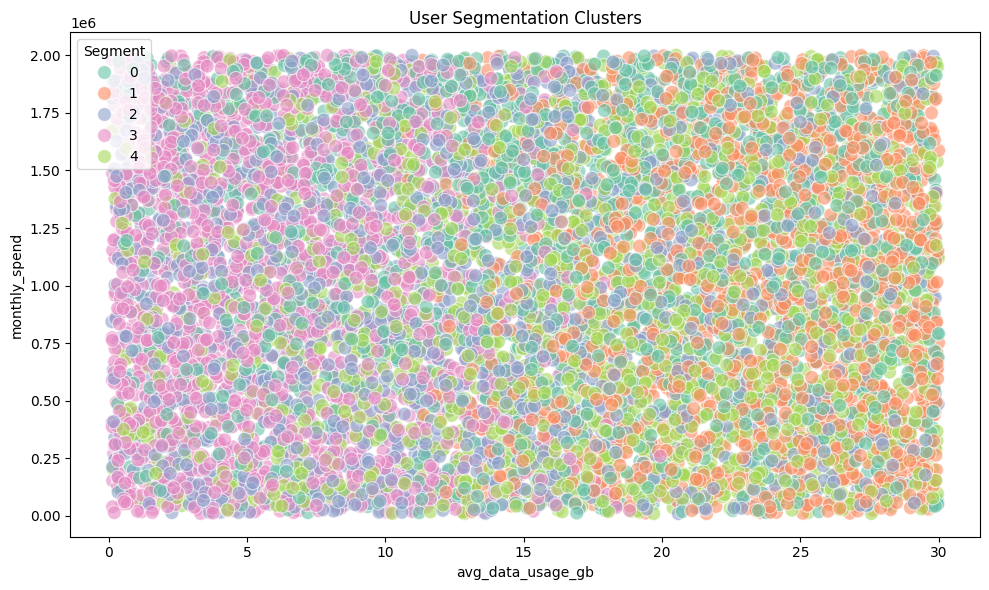

In [3]:
print("\n" + "="*50)
print("CLUSTERING - User Segmentation")
print("="*50)

# Pilih fitur untuk clustering (sesuaikan dengan kolom yang tersedia)
clustering_features = []
available_features = ['avg_data_usage_gb', 'monthly_spend', 'pct_video_usage',
                     'avg_call_duration', 'sms_freq', 'topup_freq']

for feat in available_features:
    if feat in df.columns:
        clustering_features.append(feat)

print(f"Features used for clustering: {clustering_features}")

# Buat profil user (rata-rata perilaku per customer)
user_profiles = df.groupby('customer_id')[clustering_features].mean()

# Remove rows with all NaN values
user_profiles = user_profiles.dropna(how='all')

# Fill remaining NaN with 0
user_profiles = user_profiles.fillna(0)

print(f"\nUser profiles shape: {user_profiles.shape}")
print(f"Sample user profiles:")
print(user_profiles.head())

# Scaling
scaler_cluster = StandardScaler()
X_cluster = scaler_cluster.fit_transform(user_profiles)

# KMeans clustering
n_clusters = min(5, len(user_profiles))  # Pastikan tidak lebih dari jumlah user
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
user_profiles['behavior_segment'] = kmeans.fit_predict(X_cluster)

print(f"\nSegment distribution:")
print(user_profiles['behavior_segment'].value_counts().sort_index())

# Merge cluster labels ke dataframe utama
df = df.merge(user_profiles[['behavior_segment']], on='customer_id', how='left')

# Visualisasi cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(data=user_profiles, x=clustering_features[0], y=clustering_features[1],
                hue='behavior_segment', palette='Set2', s=100, alpha=0.6)
plt.title('User Segmentation Clusters')
plt.xlabel(clustering_features[0])
plt.ylabel(clustering_features[1])
plt.legend(title='Segment')
plt.tight_layout()
plt.show()

#CANDIDATE GENERATION

In [4]:
print("\n" + "="*50)
print("CANDIDATE GENERATION")
print("="*50)

N_CANDIDATES = 10

# Top produk per segment
top_products_per_segment = (
    df.groupby('behavior_segment')['product_id']
    .value_counts()
    .groupby(level=0)
    .head(N_CANDIDATES)
    .reset_index(name='pop_score')
)

print(f"\nTop products per segment:")
print(top_products_per_segment.head(15))

# User-segment mapping
users_seg = df[['customer_id', 'behavior_segment']].drop_duplicates()

# Generate kandidat
candidates = users_seg.merge(top_products_per_segment, on='behavior_segment', how='left')
candidates = candidates[['customer_id', 'product_id', 'pop_score']].dropna()

# Ground truth (produk yang benar-benar dibeli)
actual_pairs = df[['customer_id', 'product_id']].drop_duplicates()
actual_pairs['label'] = 1

# Gabungkan kandidat dengan ground truth
candidates = candidates.merge(
    actual_pairs[['customer_id', 'product_id', 'label']],
    on=['customer_id', 'product_id'],
    how='left'
)
candidates['label'] = candidates['label'].fillna(0).astype(int)

print(f"\nTotal candidate pairs: {len(candidates)}")
print(f"Label distribution:")
print(candidates['label'].value_counts())
print(f"Positive rate: {candidates['label'].mean():.2%}")


CANDIDATE GENERATION

Top products per segment:
    behavior_segment  product_id  pop_score
0                  0          10        750
1                  0          18        305
2                  0          22        210
3                  0          23         89
4                  0           9         81
5                  0           6         73
6                  0           7         73
7                  0           8         71
8                  0          15         67
9                  0          16         60
10                 1          10        417
11                 1          14        379
12                 1          18        278
13                 1          23        211
14                 1          11         61

Total candidate pairs: 100000
Label distribution:
label
0    91642
1     8358
Name: count, dtype: int64
Positive rate: 8.36%


#FEATURE ENGINEERING

In [5]:
print("\n" + "="*50)
print("FEATURE ENGINEERING")
print("="*50)

# User features (ambil rata-rata per customer)
# Identify non-numeric columns to exclude from mean aggregation
non_numeric_cols = ['plan_type', 'device_brand', 'product_name', 'target_offer']

user_feature_cols = [col for col in df.columns if col not in
                     ['customer_id', 'product_id', 'behavior_segment',
                      'price', 'duration_days', 'data_gb', 'streaming_gb_bonus',
                      'social_gb_bonus', 'call_minutes_bonus', 'sms_bonus'] and col not in non_numeric_cols]

user_features = df.groupby('customer_id')[user_feature_cols].mean()

# Product features
product_feature_cols = ['price', 'duration_days', 'data_gb', 'streaming_gb_bonus',
                       'social_gb_bonus', 'call_minutes_bonus', 'sms_bonus']
product_feature_cols = [col for col in product_feature_cols if col in df.columns]

product_features = df.groupby('product_id')[product_feature_cols].mean()

print(f"User features: {user_features.columns.tolist()}")
print(f"Product features: {product_features.columns.tolist()}")

# Join ke candidates
train_df = candidates.copy()
train_df = train_df.merge(user_features, on='customer_id', how='left')
train_df = train_df.merge(product_features, on='product_id', how='left')

# Engineered features (hanya jika kolom yang diperlukan ada)
if 'price' in train_df.columns and 'data_gb' in train_df.columns:
    train_df['price_per_gb'] = train_df['price'] / (train_df['data_gb'] + 1)

if 'price' in train_df.columns and 'duration_days' in train_df.columns:
    train_df['price_per_day'] = train_df['price'] / (train_df['duration_days'] + 1)

if 'data_gb' in train_df.columns and 'avg_data_usage_gb' in train_df.columns:
    train_df['data_gap'] = train_df['data_gb'] - train_df['avg_data_usage_gb']

if all(col in train_df.columns for col in ['streaming_gb_bonus', 'avg_data_usage_gb', 'pct_video_usage']):
    train_df['video_coverage'] = train_df['streaming_gb_bonus'] / ((train_df['avg_data_usage_gb'] * train_df['pct_video_usage']) + 1)

# Fill NaN
train_df = train_df.fillna(0)

print(f"\nTraining data shape: {train_df.shape}")
print(f"Sample training data:")
print(train_df.head())


FEATURE ENGINEERING
User features: ['avg_data_usage_gb', 'pct_video_usage', 'avg_call_duration', 'sms_freq', 'monthly_spend', 'topup_freq', 'travel_score', 'complain_count', 'gaming_gb_bonus', 'roaming_days_bonus']
Product features: ['price', 'duration_days', 'data_gb', 'streaming_gb_bonus', 'social_gb_bonus', 'call_minutes_bonus', 'sms_bonus']

Training data shape: (100000, 25)
Sample training data:
  customer_id  product_id  pop_score  label  avg_data_usage_gb  \
0      C00001          10        750      0              17.17   
1      C00001          18        305      0              17.17   
2      C00001          22        210      1              17.17   
3      C00001          23         89      0              17.17   
4      C00001           9         81      0              17.17   

   pct_video_usage  avg_call_duration  sms_freq  monthly_spend  topup_freq  \
0            0.767             196.51     171.0      1289235.0         4.0   
1            0.767             196.51     

#MODEL TRAINING

In [6]:
print("\n" + "="*50)
print("MODEL TRAINING")
print("="*50)

# Prepare features
feature_cols = [col for col in train_df.columns if col not in
                ['customer_id', 'product_id', 'label', 'product_name', 'pop_score']]

X = train_df[feature_cols]
y = train_df['label']

print(f"Features used: {X.columns.tolist()}")
print(f"X shape: {X.shape}")
print(f"y distribution:\n{y.value_counts()}")

# Handle categorical variables if any
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Train model
model = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    C=1.0
)

print("\nTraining model...")
model.fit(X_train_scaled, y_train)
print("✓ Model training completed!")


MODEL TRAINING
Features used: ['avg_data_usage_gb', 'pct_video_usage', 'avg_call_duration', 'sms_freq', 'monthly_spend', 'topup_freq', 'travel_score', 'complain_count', 'gaming_gb_bonus', 'roaming_days_bonus', 'price', 'duration_days', 'data_gb', 'streaming_gb_bonus', 'social_gb_bonus', 'call_minutes_bonus', 'sms_bonus', 'price_per_gb', 'price_per_day', 'data_gap', 'video_coverage']
X shape: (100000, 21)
y distribution:
label
0    91642
1     8358
Name: count, dtype: int64

Training model...
✓ Model training completed!


#EVALUATION


MODEL EVALUATION

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.60      0.74     18328
           1       0.14      0.74      0.24      1672

    accuracy                           0.61     20000
   macro avg       0.55      0.67      0.49     20000
weighted avg       0.89      0.61      0.70     20000


ROC-AUC Score: 0.7252


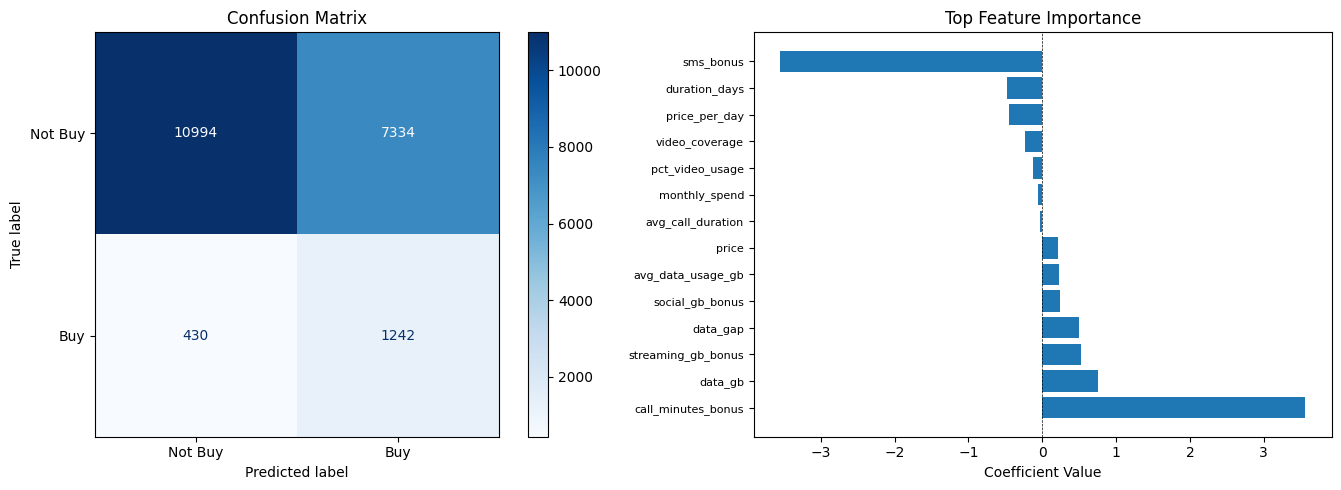


--- Top 10 Factors Driving Purchase (+) ---
               Feature  Coefficient
15  call_minutes_bonus     3.564648
12             data_gb     0.754829
13  streaming_gb_bonus     0.530084
19            data_gap     0.497815
14     social_gb_bonus     0.244291
0    avg_data_usage_gb     0.230832
10               price     0.217550
9   roaming_days_bonus     0.131802
8      gaming_gb_bonus     0.103598
17        price_per_gb     0.053860

--- Top 10 Factors Preventing Purchase (-) ---
              Feature  Coefficient
3            sms_freq     0.013657
5          topup_freq     0.011859
7      complain_count    -0.004936
2   avg_call_duration    -0.033209
4       monthly_spend    -0.052598
1     pct_video_usage    -0.128478
20     video_coverage    -0.235697
18      price_per_day    -0.443838
11      duration_days    -0.474981
16          sms_bonus    -3.550967


In [7]:
print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)

# Predictions
y_pred = model.predict(X_val_scaled)
y_proba = model.predict_proba(X_val_scaled)[:, 1]

# Classification Report
print("\n--- Classification Report ---")
print(classification_report(y_val, y_pred))

# ROC-AUC
roc_auc = roc_auc_score(y_val, y_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Not Buy', 'Buy'])
disp.plot(cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')

# Plot 2: Feature Importance
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

top_n = 15
coef_plot = pd.concat([coef_df.head(top_n//2), coef_df.tail(top_n//2)])
axes[1].barh(range(len(coef_plot)), coef_plot['Coefficient'])
axes[1].set_yticks(range(len(coef_plot)))
axes[1].set_yticklabels(coef_plot['Feature'], fontsize=8)
axes[1].set_xlabel('Coefficient Value')
axes[1].set_title('Top Feature Importance')
axes[1].axvline(x=0, color='black', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print("\n--- Top 10 Factors Driving Purchase (+) ---")
print(coef_df.head(10))

print("\n--- Top 10 Factors Preventing Purchase (-) ---")
print(coef_df.tail(10))

#GENERATE RECOMMENDATIONS

In [8]:
print("\n" + "="*50)
print("GENERATING RECOMMENDATIONS")
print("="*50)

def recommend_products(customer_id, top_n=5):
    """Generate top N product recommendations for a customer"""

    # Get customer segment
    customer_segment = df[df['customer_id'] == customer_id]['behavior_segment'].iloc[0]

    # Get candidate products for this segment
    segment_products = top_products_per_segment[
        top_products_per_segment['behavior_segment'] == customer_segment
    ]['product_id'].values

    # Prepare feature data for these products
    customer_features = user_features.loc[customer_id].to_dict()

    recommendations = []
    for product_id in segment_products:
        if product_id in product_features.index:
            prod_features = product_features.loc[product_id].to_dict()

            # Combine features
            combined = {**customer_features, **prod_features}

            # Add engineered features
            if 'price' in prod_features and 'data_gb' in prod_features:
                combined['price_per_gb'] = prod_features['price'] / (prod_features['data_gb'] + 1)
            if 'price' in prod_features and 'duration_days' in prod_features:
                combined['price_per_day'] = prod_features['price'] / (prod_features.get('duration_days', 1) + 1)
            if 'data_gb' in prod_features and 'avg_data_usage_gb' in customer_features:
                combined['data_gap'] = prod_features['data_gb'] - customer_features['avg_data_usage_gb']

            # Create DataFrame with correct feature order
            X_pred = pd.DataFrame([combined])
            X_pred = X_pred.reindex(columns=X.columns, fill_value=0)
            X_pred = pd.get_dummies(X_pred, drop_first=True)
            X_pred = X_pred.reindex(columns=X_train.columns, fill_value=0)

            # Predict probability
            X_pred_scaled = scaler.transform(X_pred)
            prob = model.predict_proba(X_pred_scaled)[0, 1]

            recommendations.append({
                'product_id': product_id,
                'probability': prob
            })

    # Sort by probability
    recommendations = sorted(recommendations, key=lambda x: x['probability'], reverse=True)
    return recommendations[:top_n]

# Test recommendations
sample_customer = df['customer_id'].iloc[0]
print(f"\nRecommendations for Customer {sample_customer}:")
recommendations = recommend_products(sample_customer, top_n=5)

for i, rec in enumerate(recommendations, 1):
    print(f"{i}. Product {rec['product_id']}: {rec['probability']:.2%} probability")

print("\n" + "="*50)
print("✓ PIPELINE COMPLETED SUCCESSFULLY!")
print("="*50)


GENERATING RECOMMENDATIONS

Recommendations for Customer C00001:
1. Product 10: 81.61% probability
2. Product 8: 57.46% probability
3. Product 18: 53.06% probability
4. Product 22: 51.96% probability
5. Product 23: 50.14% probability

✓ PIPELINE COMPLETED SUCCESSFULLY!


#EXPORT MODEL & ARTIFACTS

In [9]:
import joblib

print("\n" + "="*50)
print("SAVING MODEL TO .PKL")
print("="*50)

# Kita perlu menyimpan semua komponen yang digunakan untuk memproses data baru
# 1. Model Logistic Regression (untuk prediksi)
# 2. Scaler Model (untuk normalisasi fitur model)
# 3. Model KMeans (untuk menentukan segmen user baru)
# 4. Scaler KMeans (untuk normalisasi fitur clustering)
# 5. Data pendukung (top products, list fitur)

artifacts = {
    'model': model,
    'scaler': scaler,
    'kmeans': kmeans,
    'scaler_cluster': scaler_cluster,
    'feature_cols': X.columns.tolist(),            # List nama kolom final untuk model
    'clustering_features': clustering_features,    # List kolom untuk clustering
    'top_products_per_segment': top_products_per_segment, # Lookup table kandidat
    'product_features': product_features,          # Data fitur produk
    'user_features': user_features                 # Data fitur user (opsional, jika butuh lookup history)
}

# Simpan ke file .pkl
filename = 'logistic_regression_recommendation.pkl'
joblib.dump(artifacts, filename)

print(f"✓ Model dan artifacts berhasil disimpan ke: {filename}")
print("  File ini berisi: Model, Scaler, KMeans, dan Metadata Fitur.")


SAVING MODEL TO .PKL
✓ Model dan artifacts berhasil disimpan ke: logistic_regression_recommendation.pkl
  File ini berisi: Model, Scaler, KMeans, dan Metadata Fitur.
